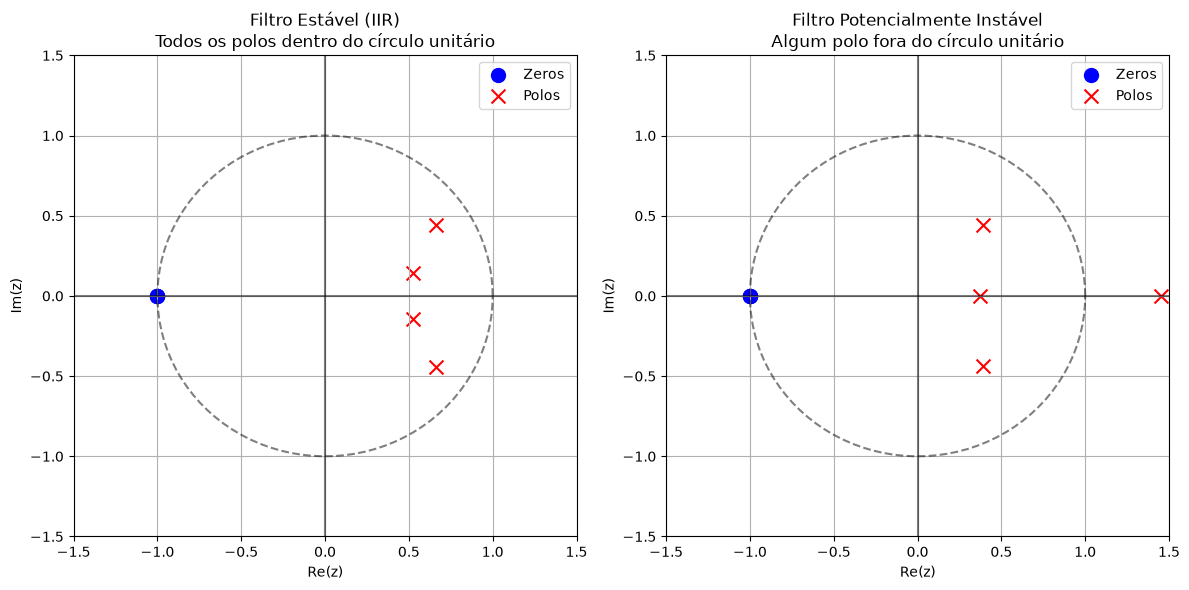

Filtro estável - Polos: [0.66045672+0.44332349j 0.66045672-0.44332349j 0.52429979+0.1457741j
 0.52429979-0.1457741j ]
Filtro estável - Todos os polos dentro do círculo unitário? True
Filtro instável - Polos: [1.45165999+0.j         0.39083916+0.43952865j 0.39083916-0.43952865j
 0.373126  +0.j        ]
Filtro instável - Todos os polos dentro do círculo unitário? False

Interpretação:
• Polos dentro do círculo unitário → Sistema estável (resposta decai)
• Polos fora do círculo unitário → Sistema instável (resposta cresce)
• Polos sobre o círculo unitário → Marginalmente estável (oscilação sustentada)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Projeto de filtro IIR estável
b_estavel, a_estavel = signal.butter(4, 0.2, btype='low')

# Projeto de filtro IIR instável (alterando manualmente um polo)
b_instavel, a_instavel = signal.butter(4, 0.2, btype='low')
# Modifica um polo para fora do círculo unitário
# Aumentando o coeficiente a1 para tornar o polo instável
a_instavel[1] = a_instavel[1] * 1.1  # Isso pode tornar o filtro instável

# Cálculo de polos e zeros
z_estavel, p_estavel, k_estavel = signal.tf2zpk(b_estavel, a_estavel)
z_instavel, p_instavel, k_instavel = signal.tf2zpk(b_instavel, a_instavel)

# Verificação de estabilidade
estavel = np.all(np.abs(p_estavel) < 1)
instavel = np.all(np.abs(p_instavel) < 1)

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Diagrama de polos e zeros - Estável
axes[0].scatter(np.real(z_estavel), np.imag(z_estavel), marker='o', color='b', s=100, label='Zeros')
axes[0].scatter(np.real(p_estavel), np.imag(p_estavel), marker='x', color='r', s=100, label='Polos')
# Círculo unitário
theta = np.linspace(0, 2*np.pi, 100)
axes[0].plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.5)
axes[0].axhline(0, color='k', alpha=0.5)
axes[0].axvline(0, color='k', alpha=0.5)
axes[0].set_xlim(-1.5, 1.5)
axes[0].set_ylim(-1.5, 1.5)
axes[0].set_xlabel('Re(z)')
axes[0].set_ylabel('Im(z)')
axes[0].set_title(f'Filtro Estável (IIR)\nTodos os polos dentro do círculo unitário')
axes[0].legend()
axes[0].grid()

# Diagrama de polos e zeros - Instável
axes[1].scatter(np.real(z_instavel), np.imag(z_instavel), marker='o', color='b', s=100, label='Zeros')
axes[1].scatter(np.real(p_instavel), np.imag(p_instavel), marker='x', color='r', s=100, label='Polos')
axes[1].plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.5)
axes[1].axhline(0, color='k', alpha=0.5)
axes[1].axvline(0, color='k', alpha=0.5)
axes[1].set_xlim(-1.5, 1.5)
axes[1].set_ylim(-1.5, 1.5)
axes[1].set_xlabel('Re(z)')
axes[1].set_ylabel('Im(z)')
axes[1].set_title(f'Filtro Potencialmente Instável\nAlgum polo fora do círculo unitário')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

print(f"Filtro estável - Polos: {p_estavel}")
print(f"Filtro estável - Todos os polos dentro do círculo unitário? {estavel}")
print(f"Filtro instável - Polos: {p_instavel}")
print(f"Filtro instável - Todos os polos dentro do círculo unitário? {instavel}")
print("\nInterpretação:")
print("• Polos dentro do círculo unitário → Sistema estável (resposta decai)")
print("• Polos fora do círculo unitário → Sistema instável (resposta cresce)")
print("• Polos sobre o círculo unitário → Marginalmente estável (oscilação sustentada)")


# Discussão dos Resultados
A estabilidade de um filtro IIR está diretamente relacionada à localização dos polos de sua função de transferência H(z). Polos dentro do círculo unitário garantem que a resposta ao impulso decaia com o tempo, resultando em sistema estável. Polos fora do círculo unitário causam crescimento exponencial da resposta, tornando o sistema instável. Esta é uma diferença fundamental em relação aos filtros FIR, que são sempre estáveis por terem todos os polos na origem.